In [60]:
import mlflow
import shap
import xgboost
import lightgbm
import joblib

print("All Day 5 packages imported successfully.")

All Day 5 packages imported successfully.


In [61]:
import warnings
import json
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import mlflow
import mlflow.sklearn
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("Day 5 libraries imported successfully.")

Day 5 libraries imported successfully.


In [62]:
data_file = Path(
    "final_modeling_dataset.csv"
)

print("Notebook folder:", Path.cwd())
print("File exists:", data_file.exists())

if not data_file.exists():
    print("\nAvailable CSV files:")

    for csv_file in Path(".").glob("*.csv"):
        print("-", csv_file.name)

    raise FileNotFoundError(
        "final_modeling_dataset.csv was not found."
    )

model_data_original = pd.read_csv(
    data_file
)

print("Dataset loaded successfully.")
print(
    "Original dataset shape:",
    model_data_original.shape
)

model_data_original.head()

Notebook folder: c:\Users\User\AMDARI Project 1
File exists: True
Dataset loaded successfully.
Original dataset shape: (10117, 21)


,production_rate_per_hour,good_units,units_produced,shift_start_hour,estimated_oee_pct,downtime_minutes,runtime_hours,defect_rate_pct,experience_runtime_interaction,temperature_deviation,...,shift_name,experience_level,cycle_time_avg,machine_prior_avg_downtime,machine_prior_avg_defect_rate,machine_id,machine_prior_avg_units,maintenance_downtime,humidity,shift_efficiency_score
0,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,...,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255
1,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,...,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255
2,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,...,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255
3,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,...,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255
4,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,...,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255


In [63]:
model_data = (
    model_data_original
    .drop_duplicates()
    .reset_index(drop=True)
)

duplicate_assessment = pd.DataFrame({
    "Measure": [
        "Original rows",
        "Exact duplicate rows",
        "Unique rows retained",
        "Duplicate percentage",
        "Missing values after deduplication"
    ],
    "Result": [
        model_data_original.shape[0],
        model_data_original.duplicated().sum(),
        model_data.shape[0],
        round(
            model_data_original.duplicated().mean()
            * 100,
            2
        ),
        model_data.isna().sum().sum()
    ]
})

duplicate_assessment

,Measure,Result
0,Original rows,10117.00
1,Exact duplicate rows,9634.00
2,Unique rows retained,483.00
3,Duplicate percentage,95.23
4,Missing values after deduplication,0.00


In [64]:
target = "shift_efficiency_score"

X = model_data.drop(
    columns=[target]
).copy()

y = model_data[target].copy()

numeric_features = (
    X.select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

dataset_summary = pd.DataFrame({
    "Measure": [
        "Evaluation rows",
        "Predictors",
        "Numerical predictors",
        "Categorical predictors",
        "Missing target values",
        "Target mean",
        "Target standard deviation"
    ],
    "Result": [
        X.shape[0],
        X.shape[1],
        len(numeric_features),
        len(categorical_features),
        y.isna().sum(),
        round(y.mean(), 2),
        round(y.std(), 2)
    ]
})

dataset_summary

,Measure,Result
0,Evaluation rows,483.00
1,Predictors,20.00
2,Numerical predictors,18.00
3,Categorical predictors,2.00
4,Missing target values,0.00
5,Target mean,79.79
6,Target standard deviation,12.92


In [65]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

split_summary = pd.DataFrame({
    "Dataset": [
        "Training set",
        "Testing set"
    ],
    "Rows": [
        X_train.shape[0],
        X_test.shape[0]
    ],
    "Percentage": [
        round(
            X_train.shape[0]
            / X.shape[0]
            * 100,
            2
        ),
        round(
            X_test.shape[0]
            / X.shape[0]
            * 100,
            2
        )
    ]
})

split_summary

,Dataset,Rows,Percentage
0,Training set,386,79.92
1,Testing set,97,20.08


In [66]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")
print(
    "Numerical predictors:",
    len(numeric_features)
)
print(
    "Categorical predictors:",
    len(categorical_features)
)

Preprocessing pipeline created.
Numerical predictors: 18
Categorical predictors: 2


In [67]:
models = {
    "Dummy Baseline": DummyRegressor(
        strategy="mean"
    ),

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=1,
        max_features=1.0,
        random_state=42,
        n_jobs=2
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=2
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1,
        n_jobs=2
    )
}

print("Number of candidate models:", len(models))

for model_name in models:
    print("-", model_name)

Number of candidate models: 6
- Dummy Baseline
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM


In [68]:
mlflow.set_tracking_uri(
    "sqlite:///nordex_mlflow.db"
)

experiment_name = (
    "NorDex Shift Efficiency Evaluation"
)

mlflow.set_experiment(
    experiment_name
)

print(
    "MLflow tracking URI:",
    mlflow.get_tracking_uri()
)

print(
    "Experiment:",
    experiment_name
)

MLflow tracking URI: sqlite:///nordex_mlflow.db
Experiment: NorDex Shift Efficiency Evaluation


In [69]:
if mlflow.active_run() is not None:
    mlflow.end_run()

model_results = []
trained_models = {}
model_predictions = {}
run_ids = {}

for model_name, estimator in models.items():
    print(f"Evaluating {model_name}...")

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                estimator
            )
        ]
    )

    with mlflow.start_run(
        run_name=model_name
    ) as current_run:

        model_pipeline.fit(
            X_train,
            y_train
        )

        predictions = model_pipeline.predict(
            X_test
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        r_squared = r2_score(
            y_test,
            predictions
        )

        mlflow.log_params({
            "model_name": model_name,
            "training_rows": X_train.shape[0],
            "testing_rows": X_test.shape[0],
            "predictor_count": X_train.shape[1],
            "duplicates_removed": 9634,
            "random_state": 42
        })

        mlflow.log_metrics({
            "test_mae": mae,
            "test_rmse": rmse,
            "test_r2": r_squared
        })

        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            artifact_path="model",
            skops_trusted_types=[
                "numpy.dtype"
            ]
        )

        run_ids[model_name] = (
            current_run.info.run_id
        )

    trained_models[model_name] = (
        model_pipeline
    )

    model_predictions[model_name] = (
        predictions
    )

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R-squared": r_squared,
        "MLflow run ID":
            run_ids[model_name]
    })

    print(
        f"{model_name} completed."
    )

print("\nAll model experiments completed.")

Evaluating Dummy Baseline...


2026/09/19 13:33:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/19 13:33:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Dummy Baseline completed.
Evaluating Linear Regression...
Linear Regression completed.
Evaluating Random Forest...


2026/09/19 13:34:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['sklearn.tree._tree.Tree'].

- sklearn.tree._tree.Tree: sklearn.tree._tree.Tree (the shared node storage for DecisionTree*, RandomForest*, ExtraTrees*, and GradientBoosting* models) stores raw node indices (left_child, right_child, feature) that scikit-learn indexes into without bounds checking. A malicious file can set these to out-of-range values: skops loads the object successfully, but calling .predict() on it can then crash the process (segfault) or read out-of-bounds memory. If you created the file yourself or otherwise fully trust its source, you can load it with trusted=["sklearn.tree._tree.Tree"].

Only add the specific types you have reviewed and trust to the `trusted` argument; avoid passing everything repo

In [70]:
if mlflow.active_run() is not None:
    mlflow.end_run()

print("Previous MLflow run closed.")

Previous MLflow run closed.


In [71]:
model_results = []
trained_models = {}
model_predictions = {}
run_ids = {}

for model_name, estimator in models.items():
    print(f"Evaluating {model_name}...")

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                estimator
            )
        ]
    )

    with mlflow.start_run(
        run_name=model_name
    ) as current_run:

        model_pipeline.fit(
            X_train,
            y_train
        )

        predictions = model_pipeline.predict(
            X_test
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        r_squared = r2_score(
            y_test,
            predictions
        )

        mlflow.log_params({
            "model_name": model_name,
            "training_rows": X_train.shape[0],
            "testing_rows": X_test.shape[0],
            "predictor_count": X_train.shape[1],
            "duplicates_removed": 9634,
            "random_state": 42
        })

        mlflow.log_metrics({
            "test_mae": mae,
            "test_rmse": rmse,
            "test_r2": r_squared
        })

        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            artifact_path="model",
            serialization_format="cloudpickle"
        )

        run_ids[model_name] = (
            current_run.info.run_id
        )

    trained_models[model_name] = (
        model_pipeline
    )

    model_predictions[model_name] = (
        predictions
    )

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R-squared": r_squared,
        "MLflow run ID":
            run_ids[model_name]
    })

    print(
        f"{model_name} completed."
    )

print("\nAll model experiments completed.")

Evaluating Dummy Baseline...


2026/09/19 13:36:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/19 13:36:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/19 13:36:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Dummy Baseline completed.
Evaluating Linear Regression...


2026/09/19 13:36:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression completed.
Evaluating Random Forest...


...

Gradient Boosting completed.
Evaluating XGBoost...


2026/09/19 13:37:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/19 13:37:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost completed.
Evaluating LightGBM...


2026/09/19 13:37:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/19 13:37:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM completed.

All model experiments completed.


In [72]:
final_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

final_comparison[
    [
        "Model",
        "MAE",
        "RMSE",
        "R-squared"
    ]
].round(4)

,Model,MAE,RMSE,R-squared
0,Gradient Boosting,2.3619,2.9827,0.9369
1,Random Forest,2.3864,2.9946,0.9364
2,LightGBM,2.4609,3.0208,0.9353
3,XGBoost,2.4762,3.1467,0.9298
4,Linear Regression,2.6725,3.2809,0.9236
5,Dummy Baseline,9.8158,11.8736,-0.0000


In [73]:
final_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

final_comparison[
    [
        "Model",
        "MAE",
        "RMSE",
        "R-squared"
    ]
].round(4)

,Model,MAE,RMSE,R-squared
0,Gradient Boosting,2.3619,2.9827,0.9369
1,Random Forest,2.3864,2.9946,0.9364
2,LightGBM,2.4609,3.0208,0.9353
3,XGBoost,2.4762,3.1467,0.9298
4,Linear Regression,2.6725,3.2809,0.9236
5,Dummy Baseline,9.8158,11.8736,-0.0000


In [74]:
if mlflow.active_run() is not None:
    mlflow.end_run()

model_results = []
trained_models = {}
model_predictions = {}
run_ids = {}

for model_name, estimator in models.items():
    print(f"Evaluating {model_name}...")

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                estimator
            )
        ]
    )

    with mlflow.start_run(
        run_name=model_name
    ) as current_run:

        model_pipeline.fit(
            X_train,
            y_train
        )

        predictions = model_pipeline.predict(
            X_test
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        r_squared = r2_score(
            y_test,
            predictions
        )

        mlflow.log_params({
            "model_name": model_name,
            "training_rows": X_train.shape[0],
            "testing_rows": X_test.shape[0],
            "predictor_count": X_train.shape[1],
            "duplicates_removed": 9634,
            "random_state": 42
        })

        mlflow.log_metrics({
            "test_mae": mae,
            "test_rmse": rmse,
            "test_r2": r_squared
        })

        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            artifact_path="model",
            skops_trusted_types=[
                "numpy.dtype"
            ]
        )

        run_ids[model_name] = (
            current_run.info.run_id
        )

    trained_models[model_name] = (
        model_pipeline
    )

    model_predictions[model_name] = (
        predictions
    )

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R-squared": r_squared,
        "MLflow run ID":
            run_ids[model_name]
    })

    print(
        f"{model_name} completed."
    )

print("\nAll model experiments completed.")

Evaluating Dummy Baseline...


2026/09/19 13:38:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/19 13:38:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Dummy Baseline completed.
Evaluating Linear Regression...
Linear Regression completed.
Evaluating Random Forest...


2026/09/19 13:38:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['sklearn.tree._tree.Tree'].

- sklearn.tree._tree.Tree: sklearn.tree._tree.Tree (the shared node storage for DecisionTree*, RandomForest*, ExtraTrees*, and GradientBoosting* models) stores raw node indices (left_child, right_child, feature) that scikit-learn indexes into without bounds checking. A malicious file can set these to out-of-range values: skops loads the object successfully, but calling .predict() on it can then crash the process (segfault) or read out-of-bounds memory. If you created the file yourself or otherwise fully trust its source, you can load it with trusted=["sklearn.tree._tree.Tree"].

Only add the specific types you have reviewed and trust to the `trusted` argument; avoid passing everything repo

In [75]:
if mlflow.active_run() is not None:
    mlflow.end_run()

print("Failed run closed.")

Failed run closed.


In [ ]:
print(
    mlflow.sklearn
    .SERIALIZATION_FORMAT_CLOUDPICKLE
)

cloudpickle


In [ ]:
if mlflow.active_run() is not None:
    mlflow.end_run()

model_results = []
trained_models = {}
model_predictions = {}
run_ids = {}

for model_name, estimator in models.items():
    print(f"Evaluating {model_name}...")

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                estimator
            )
        ]
    )

    with mlflow.start_run(
        run_name=model_name
    ) as current_run:

        model_pipeline.fit(
            X_train,
            y_train
        )

        predictions = model_pipeline.predict(
            X_test
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        r_squared = r2_score(
            y_test,
            predictions
        )

        mlflow.log_params({
            "model_name": model_name,
            "training_rows": X_train.shape[0],
            "testing_rows": X_test.shape[0],
            "predictor_count": X_train.shape[1],
            "duplicates_removed": 9634,
            "random_state": 42
        })

        mlflow.log_metrics({
            "test_mae": mae,
            "test_rmse": rmse,
            "test_r2": r_squared
        })

        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            artifact_path="model",
            serialization_format=(
                mlflow.sklearn
                .SERIALIZATION_FORMAT_CLOUDPICKLE
            )
        )

        run_ids[model_name] = (
            current_run.info.run_id
        )

    trained_models[model_name] = (
        model_pipeline
    )

    model_predictions[model_name] = (
        predictions
    )

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R-squared": r_squared,
        "MLflow run ID":
            run_ids[model_name]
    })

    print(
        f"{model_name} completed."
    )

print("\nAll model experiments completed.")

Evaluating Dummy Baseline...


2026/09/18 09:36:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/18 09:36:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/18 09:36:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Dummy Baseline completed.
Evaluating Linear Regression...


2026/09/18 09:36:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression completed.
Evaluating Random Forest...


...

Gradient Boosting completed.
Evaluating XGBoost...


2026/09/18 09:37:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/18 09:37:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost completed.
Evaluating LightGBM...


2026/09/18 09:37:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/18 09:37:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM completed.

All model experiments completed.


In [ ]:
serialization_format=(
    mlflow.sklearn
    .SERIALIZATION_FORMAT_CLOUDPICKLE
)

In [ ]:
final_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

final_comparison[
    [
        "Model",
        "MAE",
        "RMSE",
        "R-squared"
    ]
].round(4)

,Model,MAE,RMSE,R-squared
0,Gradient Boosting,2.3619,2.9827,0.9369
1,Random Forest,2.3864,2.9946,0.9364
2,LightGBM,2.4609,3.0208,0.9353
3,XGBoost,2.4762,3.1467,0.9298
4,Linear Regression,2.6725,3.2809,0.9236
5,Dummy Baseline,9.8158,11.8736,-0.0000


In [ ]:
cross_validation_results = []

for model_name, model_pipeline in (
    trained_models.items()
):
    if model_name == "Dummy Baseline":
        continue

    cv_scores = cross_validate(
        model_pipeline,
        X,
        y,
        cv=5,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse":
                "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=2
    )

    cross_validation_results.append({
        "Model": model_name,
        "CV MAE": (
            -cv_scores["test_mae"].mean()
        ),
        "CV RMSE": (
            -cv_scores["test_rmse"].mean()
        ),
        "CV R-squared": (
            cv_scores["test_r2"].mean()
        ),
        "RMSE standard deviation": (
            cv_scores["test_rmse"].std()
        )
    })

cv_comparison = (
    pd.DataFrame(
        cross_validation_results
    )
    .sort_values(
        "CV RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

cv_comparison.round(4)

,Model,CV MAE,CV RMSE,CV R-squared,RMSE standard deviation
0,Random Forest,2.5215,3.1657,0.8992,0.2313
1,Gradient Boosting,2.5872,3.2010,0.8981,0.2036
2,LightGBM,2.6122,3.2420,0.8912,0.2245
3,XGBoost,2.6351,3.2689,0.8918,0.2445
4,Linear Regression,2.6312,3.2822,0.8893,0.2322


In [ ]:
best_model_name = (
    cv_comparison.iloc[0]["Model"]
)

final_model = (
    trained_models[best_model_name]
)

final_predictions = (
    model_predictions[best_model_name]
)

final_run_id = (
    run_ids[best_model_name]
)

selection_summary = pd.DataFrame({
    "Selection measure": [
        "Selected model",
        "Test MAE",
        "Test RMSE",
        "Test R-squared",
        "Cross-validation RMSE",
        "Cross-validation R-squared",
        "Selection basis"
    ],
    "Result": [
        best_model_name,
        round(
            final_comparison.loc[
                final_comparison["Model"]
                == best_model_name,
                "MAE"
            ].iloc[0],
            4
        ),
        round(
            final_comparison.loc[
                final_comparison["Model"]
                == best_model_name,
                "RMSE"
            ].iloc[0],
            4
        ),
        round(
            final_comparison.loc[
                final_comparison["Model"]
                == best_model_name,
                "R-squared"
            ].iloc[0],
            4
        ),
        round(
            cv_comparison.iloc[0][
                "CV RMSE"
            ],
            4
        ),
        round(
            cv_comparison.iloc[0][
                "CV R-squared"
            ],
            4
        ),
        (
            "Lowest five-fold "
            "cross-validation RMSE"
        )
    ]
})

selection_summary

,Selection measure,Result
0,Selected model,Random Forest
1,Test MAE,2.3864
2,Test RMSE,2.9946
3,Test R-squared,0.9364
4,Cross-validation RMSE,3.1657
5,Cross-validation R-squared,0.8992
6,Selection basis,Lowest five-fold cross-validation RMSE


In [ ]:
fitted_preprocessor = (
    final_model.named_steps[
        "preprocessor"
    ]
)

fitted_estimator = (
    final_model.named_steps[
        "model"
    ]
)

transformed_feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

if hasattr(
    fitted_estimator,
    "feature_importances_"
):
    feature_importance = pd.DataFrame({
        "Feature":
            transformed_feature_names,
        "Importance":
            fitted_estimator
            .feature_importances_
    })

    feature_importance = (
        feature_importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(
        feature_importance.head(15)
    )

else:
    print(
        "The selected model does not provide "
        "tree-based feature importance."
    )

,Feature,Importance
0,numerical__production_rate_per_hour,0.552037
1,numerical__units_produced,0.212924
2,numerical__good_units,0.087439
3,numerical__temperature_deviation,0.029112
4,numerical__shift_start_hour,0.020931
5,numerical__estimated_oee_pct,0.019108
6,categorical__shift_name_Evening,0.018431
7,categorical__shift_name_Morning,0.015003
8,numerical__downtime_minutes,0.009100
9,numerical__runtime_hours,0.004317


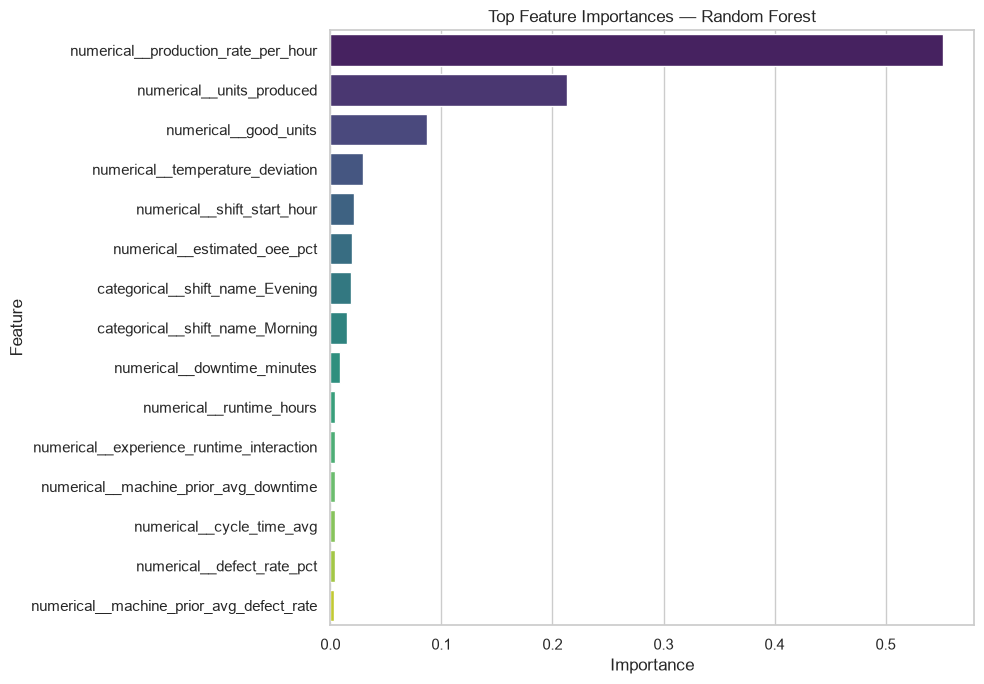

In [ ]:
if hasattr(
    fitted_estimator,
    "feature_importances_"
):
    top_features = (
        feature_importance.head(15)
    )

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="viridis",
        legend=False
    )

    plt.title(
        f"Top Feature Importances — "
        f"{best_model_name}"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

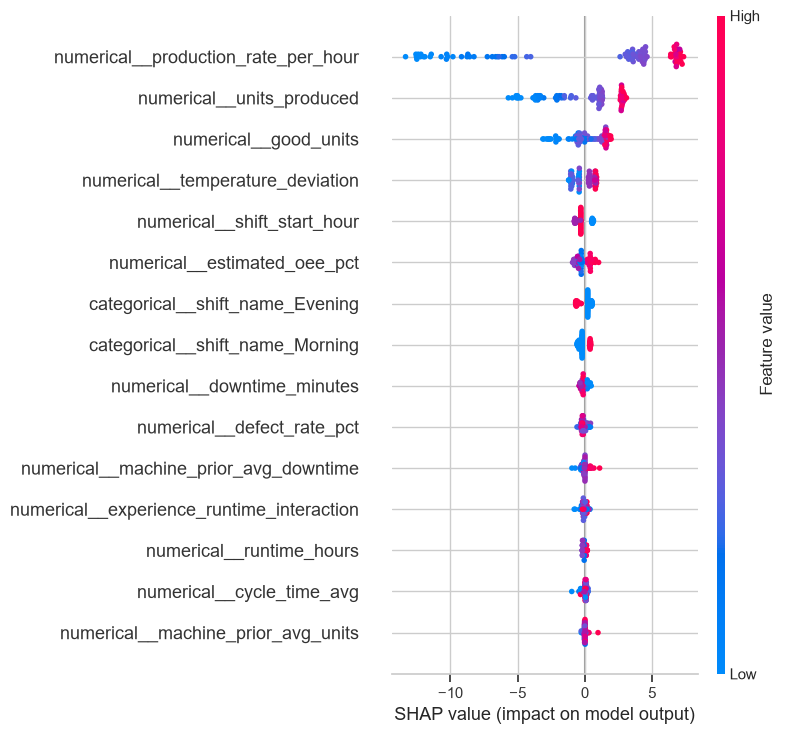

In [ ]:
X_test_transformed = (
    fitted_preprocessor.transform(
        X_test
    )
)

if hasattr(
    X_test_transformed,
    "toarray"
):
    X_test_transformed = (
        X_test_transformed.toarray()
    )

sample_size = min(
    100,
    X_test_transformed.shape[0]
)

shap_input = (
    X_test_transformed[:sample_size]
)

explainer = shap.TreeExplainer(
    fitted_estimator
)

shap_values = explainer.shap_values(
    shap_input
)

shap.summary_plot(
    shap_values,
    shap_input,
    feature_names=(
        transformed_feature_names
    ),
    max_display=15,
    show=True
)

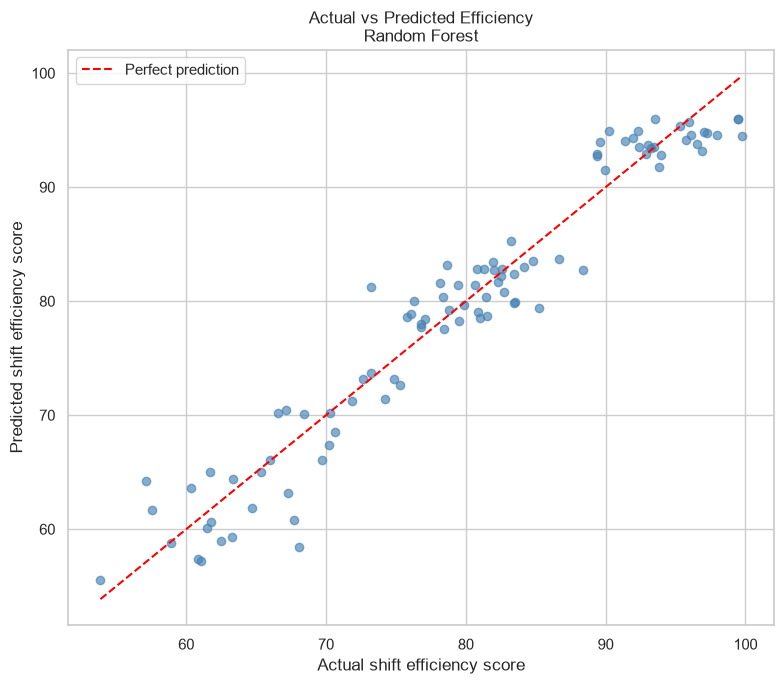

In [ ]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.65,
    color="steelblue"
)

minimum_value = min(
    y_test.min(),
    final_predictions.min()
)

maximum_value = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    label="Perfect prediction"
)

plt.title(
    f"Actual vs Predicted Efficiency\n"
    f"{best_model_name}"
)

plt.xlabel(
    "Actual shift efficiency score"
)

plt.ylabel(
    "Predicted shift efficiency score"
)

plt.legend()
plt.tight_layout()
plt.show()

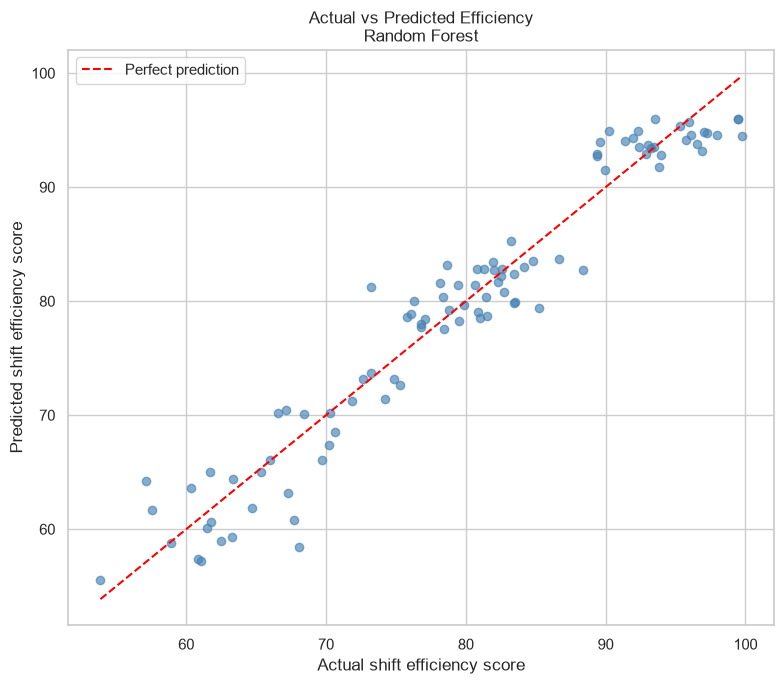

In [ ]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.65,
    color="steelblue"
)

minimum_value = min(
    y_test.min(),
    final_predictions.min()
)

maximum_value = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    label="Perfect prediction"
)

plt.title(
    f"Actual vs Predicted Efficiency\n"
    f"{best_model_name}"
)

plt.xlabel(
    "Actual shift efficiency score"
)

plt.ylabel(
    "Predicted shift efficiency score"
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
registered_model_name = (
    "NorDex_Shift_Efficiency_Model"
)

model_uri = (
    f"runs:/{final_run_id}/model"
)

registered_model = (
    mlflow.register_model(
        model_uri=model_uri,
        name=registered_model_name
    )
)

print(
    "Registered model:",
    registered_model.name
)

print(
    "Registered version:",
    registered_model.version
)

Successfully registered model 'NorDex_Shift_Efficiency_Model'.
2026/09/18 09:41:53 WARNING mlflow.tracking._model_registry.fluent: Run with id 84de9b27f8c5440e82c7e7fc1f288063 has no artifacts at artifact path 'model', registering model based on models:/m-1888c7b9f3c34acbb1fe0d6421723084 instead


Registered model: NorDex_Shift_Efficiency_Model
Registered version: 1


Created version '1' of model 'NorDex_Shift_Efficiency_Model'.


In [ ]:
production_model_path = Path(
    "final_production_candidate.joblib"
)

joblib.dump(
    final_model,
    production_model_path,
    compress=3
)

print(
    "Final model:",
    best_model_name
)

print(
    "Model file:",
    production_model_path
)

print(
    "Model file exists:",
    production_model_path.exists()
)

Final model: Random Forest
Model file: final_production_candidate.joblib
Model file exists: True


In [ ]:
final_comparison.to_csv(
    "day5_final_model_comparison.csv",
    index=False
)

cv_comparison.to_csv(
    "day5_cross_validation_results.csv",
    index=False
)

feature_importance.to_csv(
    "day5_feature_importance.csv",
    index=False
)

selection_summary.to_csv(
    "day5_final_model_selection.csv",
    index=False
)

print("Day 5 exports completed.")

for output_file in [
    "day5_final_model_comparison.csv",
    "day5_cross_validation_results.csv",
    "day5_feature_importance.csv",
    "day5_final_model_selection.csv",
    "final_production_candidate.joblib",
    "nordex_mlflow.db"
]:
    print(
        output_file,
        "—",
        Path(output_file).exists()
    )

Day 5 exports completed.
day5_final_model_comparison.csv — True
day5_cross_validation_results.csv — True
day5_feature_importance.csv — True
day5_final_model_selection.csv — True
final_production_candidate.joblib — True
nordex_mlflow.db — True


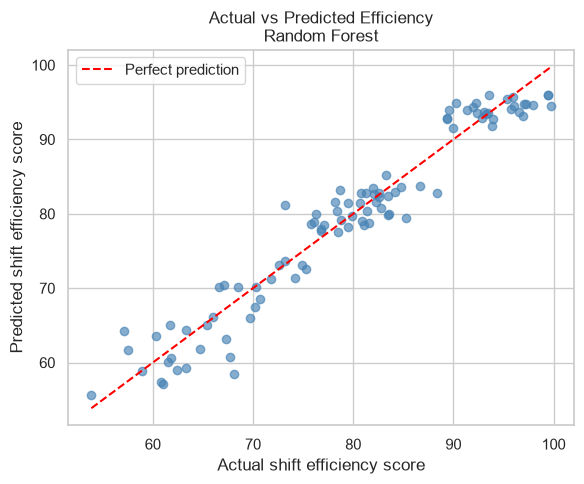

In [ ]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.65,
    color="steelblue"
)

minimum_value = min(
    y_test.min(),
    final_predictions.min()
)

maximum_value = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    label="Perfect prediction"
)

plt.title(
    "Actual vs Predicted Efficiency\n"
    "Random Forest"
)

plt.xlabel(
    "Actual shift efficiency score"
)

plt.ylabel(
    "Predicted shift efficiency score"
)

plt.legend()
plt.tight_layout()
plt.show()

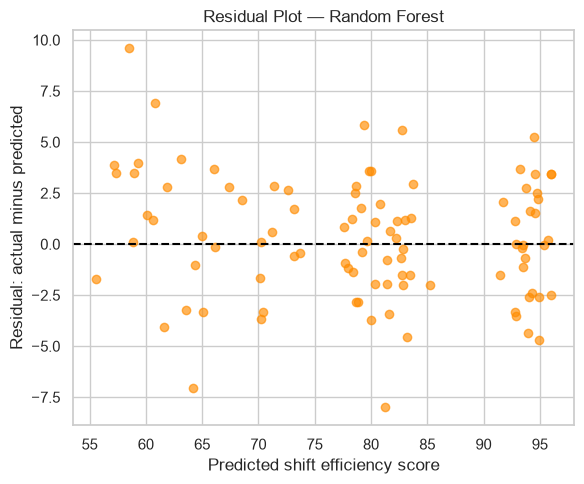

In [ ]:
final_residuals = (
    y_test.to_numpy()
    - final_predictions
)

plt.figure(figsize=(6, 5))

plt.scatter(
    final_predictions,
    final_residuals,
    alpha=0.65,
    color="darkorange"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Residual Plot — Random Forest"
)

plt.xlabel(
    "Predicted shift efficiency score"
)

plt.ylabel(
    "Residual: actual minus predicted"
)

plt.tight_layout()
plt.show()

In [ ]:
registered_model_name = (
    "NorDex_Shift_Efficiency_Model"
)

with mlflow.start_run(
    run_name="Final Random Forest Registration"
) as registration_run:

    mlflow.log_params({
        "model_name": "Random Forest",
        "training_rows": X_train.shape[0],
        "testing_rows": X_test.shape[0],
        "predictor_count": X_train.shape[1],
        "duplicates_removed": 9634
    })

    mlflow.log_metrics({
        "test_mae": 2.3864,
        "test_rmse": 2.9946,
        "test_r2": 0.9364,
        "cv_rmse": 3.1657,
        "cv_r2": 0.8992
    })

    final_model_information = (
        mlflow.sklearn.log_model(
            sk_model=final_model,
            artifact_path="final_model",
            registered_model_name=(
                registered_model_name
            ),
            serialization_format=(
                mlflow.sklearn
                .SERIALIZATION_FORMAT_CLOUDPICKLE
            )
        )
    )

    final_registration_run_id = (
        registration_run.info.run_id
    )

print(
    "Final registration run:",
    final_registration_run_id
)

print(
    "Registered model:",
    registered_model_name
)

2026/09/18 14:26:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/18 14:26:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final registration run: 0f824710fb39487eb35f583f4c35ecb1
Registered model: NorDex_Shift_Efficiency_Model


Registered model 'NorDex_Shift_Efficiency_Model' already exists. Creating a new version of this model...
Created version '2' of model 'NorDex_Shift_Efficiency_Model'.


In [ ]:
from mlflow import MlflowClient

client = MlflowClient()

latest_versions = (
    client.search_model_versions(
        f"name='{registered_model_name}'"
    )
)

latest_version = max(
    int(version.version)
    for version in latest_versions
)

client.set_registered_model_alias(
    name=registered_model_name,
    alias="candidate",
    version=str(latest_version)
)

print(
    "Candidate alias assigned to version:",
    latest_version
)

Candidate alias assigned to version: 2


In [ ]:
production_model_path = Path(
    "final_production_candidate.joblib"
)

joblib.dump(
    final_model,
    production_model_path,
    compress=3
)

print(
    "Final model:",
    best_model_name
)

print(
    "Model file:",
    production_model_path
)

print(
    "Model file exists:",
    production_model_path.exists()
)

Final model: Random Forest
Model file: final_production_candidate.joblib
Model file exists: True


In [ ]:
print("Day 5 exports completed.")

for output_file in [
    "day5_final_model_comparison.csv",
    "day5_cross_validation_results.csv",
    "day5_feature_importance.csv",
    "day5_final_model_selection.csv",
    "final_production_candidate.joblib",
    "nordex_mlflow.db"
]:
    print(
        output_file,
        "—",
        Path(output_file).exists()
    )

Day 5 exports completed.
day5_final_model_comparison.csv — True
day5_cross_validation_results.csv — True
day5_feature_importance.csv — True
day5_final_model_selection.csv — True
final_production_candidate.joblib — True
nordex_mlflow.db — True


In [76]:
feature_importance.head(15)

,Feature,Importance
0,numerical__production_rate_per_hour,0.552037
1,numerical__units_produced,0.212924
2,numerical__good_units,0.087439
3,numerical__temperature_deviation,0.029112
4,numerical__shift_start_hour,0.020931
5,numerical__estimated_oee_pct,0.019108
6,categorical__shift_name_Evening,0.018431
7,categorical__shift_name_Morning,0.015003
8,numerical__downtime_minutes,0.009100
9,numerical__runtime_hours,0.004317


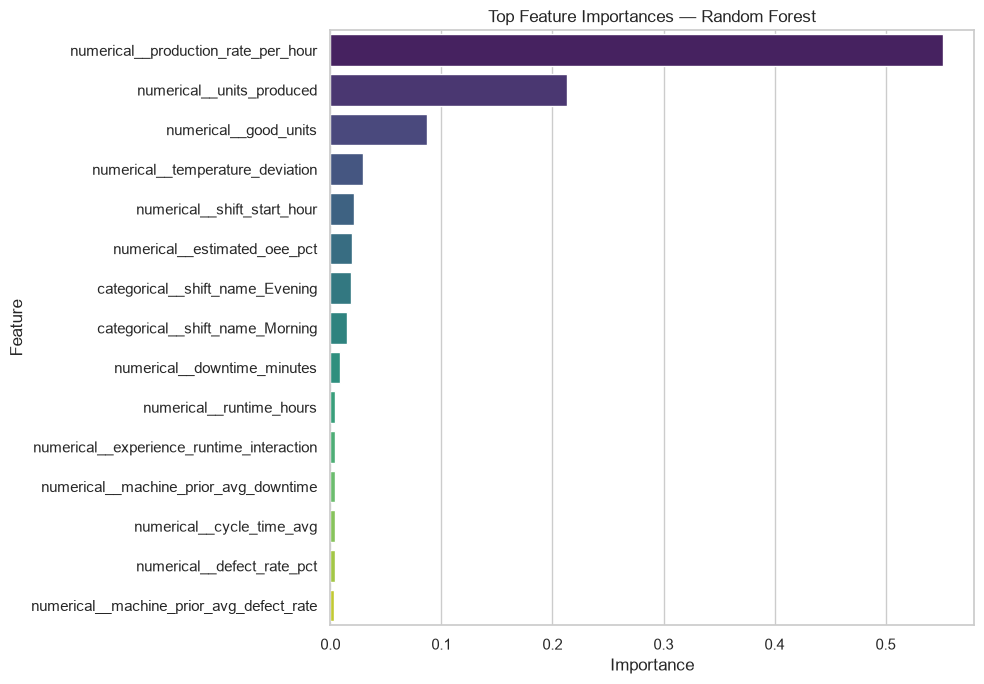

In [77]:
top_features = (
    feature_importance.head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top Feature Importances — Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [78]:
cv_comparison.round(4)

,Model,CV MAE,CV RMSE,CV R-squared,RMSE standard deviation
0,Random Forest,2.5215,3.1657,0.8992,0.2313
1,Gradient Boosting,2.5872,3.2010,0.8981,0.2036
2,LightGBM,2.6122,3.2420,0.8912,0.2245
3,XGBoost,2.6351,3.2689,0.8918,0.2445
4,Linear Regression,2.6312,3.2822,0.8893,0.2322


In [79]:
final_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

final_comparison[
    [
        "Model",
        "MAE",
        "RMSE",
        "R-squared"
    ]
].round(4)

,Model,MAE,RMSE,R-squared
0,Linear Regression,2.6725,3.2809,0.9236
1,Dummy Baseline,9.8158,11.8736,-0.0000


In [80]:
mlflow.set_tracking_uri(
    "sqlite:///nordex_mlflow.db"
)

experiment_name = (
    "NorDex Shift Efficiency Evaluation"
)

mlflow.set_experiment(
    experiment_name
)

print(
    "MLflow tracking URI:",
    mlflow.get_tracking_uri()
)

print(
    "Experiment:",
    experiment_name
)

MLflow tracking URI: sqlite:///nordex_mlflow.db
Experiment: NorDex Shift Efficiency Evaluation


In [81]:
print("Number of candidate models:", len(models))

for model_name in models:
    print("-", model_name)

Number of candidate models: 6
- Dummy Baseline
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM


In [82]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")
print("Numerical predictors:", len(numeric_features))
print("Categorical predictors:", len(categorical_features))

Preprocessing pipeline created.
Numerical predictors: 18
Categorical predictors: 2


In [ ]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

split_summary = pd.DataFrame({
    "Dataset": [
        "Training set",
        "Testing set"
    ],
    "Rows": [
        X_train.shape[0],
        X_test.shape[0]
    ],
    "Percentage": [
        round(
            X_train.shape[0]
            / X.shape[0]
            * 100,
            2
        ),
        round(
            X_test.shape[0]
            / X.shape[0]
            * 100,
            2
        )
    ]
})target = "shift_efficiency_score"

X = model_data.drop(
    columns=[target]
).copy()

y = model_data[target].copy()

numeric_features = (
    X.select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

dataset_summary = pd.DataFrame({
    "Measure": [
        "Evaluation rows",
        "Predictors",
        "Numerical predictors",
        "Categorical predictors",
        "Missing target values",
        "Target mean",
        "Target standard deviation"
    ],
    "Result": [
        X.shape[0],
        X.shape[1],
        len(numeric_features),
        len(categorical_features),
        y.isna().sum(),
        round(y.mean(), 2),
        round(y.std(), 2)
    ]
})

dataset_summary

split_summary

,Dataset,Rows,Percentage
0,Training set,386,79.92
1,Testing set,97,20.08


In [84]:
target = "shift_efficiency_score"

X = model_data.drop(
    columns=[target]
).copy()

y = model_data[target].copy()

numeric_features = (
    X.select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

dataset_summary = pd.DataFrame({
    "Measure": [
        "Evaluation rows",
        "Predictors",
        "Numerical predictors",
        "Categorical predictors",
        "Missing target values",
        "Target mean",
        "Target standard deviation"
    ],
    "Result": [
        X.shape[0],
        X.shape[1],
        len(numeric_features),
        len(categorical_features),
        y.isna().sum(),
        round(y.mean(), 2),
        round(y.std(), 2)
    ]
})

dataset_summary

,Measure,Result
0,Evaluation rows,483.00
1,Predictors,20.00
2,Numerical predictors,18.00
3,Categorical predictors,2.00
4,Missing target values,0.00
5,Target mean,79.79
6,Target standard deviation,12.92


In [85]:
model_data = (
    model_data_original
    .drop_duplicates()
    .reset_index(drop=True)
)

duplicate_assessment = pd.DataFrame({
    "Measure": [
        "Original rows",
        "Exact duplicate rows",
        "Unique rows retained",
        "Duplicate percentage",
        "Missing values after deduplication"
    ],
    "Result": [
        model_data_original.shape[0],
        model_data_original.duplicated().sum(),
        model_data.shape[0],
        round(
            model_data_original.duplicated().mean()
            * 100,
            2
        ),
        model_data.isna().sum().sum()
    ]
})

duplicate_assessment

,Measure,Result
0,Original rows,10117.00
1,Exact duplicate rows,9634.00
2,Unique rows retained,483.00
3,Duplicate percentage,95.23
4,Missing values after deduplication,0.00


In [90]:
unseen_category_test = sample_input.copy()

if categorical_columns:
    test_categorical_column = categorical_columns[0]

    unseen_category_test.loc[
        unseen_category_test.index[0],
        test_categorical_column
    ] = "Previously_Unseen_Category"

    unseen_predictions = production_pipeline.predict(
        unseen_category_test
    )

    print("Unseen-category test passed.")
    print(
        "Tested column:",
        test_categorical_column
    )

    display(unseen_predictions)

else:
    print(
        "No categorical predictors were detected, "
        "so this test was not required."
    )

Unseen-category test passed.
Tested column: shift_name


,predicted_shift_efficiency_score,prediction_timestamp_utc,pipeline_status
0,94.730059,2026-09-20T20:38:12.124842+00:00,Successful
1,95.747173,2026-09-20T20:38:12.124842+00:00,Successful
2,95.747173,2026-09-20T20:38:12.124842+00:00,Successful
3,95.747173,2026-09-20T20:38:12.124842+00:00,Successful
4,95.747173,2026-09-20T20:38:12.124842+00:00,Successful


In [89]:
# Recreate the five-row sample input if it is missing.
sample_input = reference_features.head(5).copy()

unseen_category_test = sample_input.copy()

if categorical_columns:
    test_categorical_column = categorical_columns[0]

    original_category = unseen_category_test.loc[
        unseen_category_test.index[0],
        test_categorical_column
    ]

    unseen_category_test.loc[
        unseen_category_test.index[0],
        test_categorical_column
    ] = "Previously_Unseen_Category"

    unseen_predictions = production_pipeline.predict(
        unseen_category_test
    )

    print("Unseen-category test passed.")
    print(
        "Tested column:",
        test_categorical_column
    )
    print(
        "Original category:",
        original_category
    )
    print(
        "New unseen category:",
        "Previously_Unseen_Category"
    )

    display(unseen_predictions)

else:
    print(
        "No categorical predictors were detected, "
        "so this test was not required."
    )

Unseen-category test passed.
Tested column: shift_name
Original category: Morning
New unseen category: Previously_Unseen_Category


,predicted_shift_efficiency_score,prediction_timestamp_utc,pipeline_status
0,94.730059,2026-09-20T20:38:08.082109+00:00,Successful
1,95.747173,2026-09-20T20:38:08.082109+00:00,Successful
2,95.747173,2026-09-20T20:38:08.082109+00:00,Successful
3,95.747173,2026-09-20T20:38:08.082109+00:00,Successful
4,95.747173,2026-09-20T20:38:08.082109+00:00,Successful


In [88]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import importlib

# Recreate project paths.
project_folder = Path.cwd()

model_file = (
    project_folder
    / "final_production_candidate.joblib"
)

possible_data_files = [
    project_folder / "final_modeling_dataset.csv",
    project_folder / "final_modeling_dataset(1).csv"
]

data_file = next(
    (
        file
        for file in possible_data_files
        if file.exists()
    ),
    None
)

if data_file is None:
    raise FileNotFoundError(
        "The final modeling dataset was not found."
    )

# Reload dataset and model.
manufacturing_data = pd.read_csv(data_file)
local_model = joblib.load(model_file)

target_column = "shift_efficiency_score"

# Recover the exact model features.
expected_columns = list(
    local_model.feature_names_in_
)

reference_features = manufacturing_data[
    expected_columns
].copy()

numerical_columns = (
    reference_features.select_dtypes(
        include=np.number
    ).columns.tolist()
)

categorical_columns = [
    column
    for column in expected_columns
    if column not in numerical_columns
]

# Reload the production pipeline class.
import production_pipeline as pipeline_module

importlib.reload(pipeline_module)

ManufacturingPredictionPipeline = (
    pipeline_module.ManufacturingPredictionPipeline
)

production_pipeline = ManufacturingPredictionPipeline(
    model=local_model,
    expected_columns=expected_columns,
    numerical_columns=numerical_columns,
    categorical_columns=categorical_columns
)

sample_input = reference_features.head(5).copy()

print("Notebook variables recovered successfully.")
print("Dataset:", data_file.name)
print("Reference rows:", len(reference_features))
print("Expected predictors:", len(expected_columns))
print("Numerical predictors:", len(numerical_columns))
print("Categorical predictors:", categorical_columns)
print("Sample rows:", len(sample_input))

Notebook variables recovered successfully.
Dataset: final_modeling_dataset.csv
Reference rows: 10117
Expected predictors: 20
Numerical predictors: 18
Categorical predictors: ['shift_name', 'machine_id']
Sample rows: 5


In [91]:
tracking_uri = (
    "sqlite:///"
    + mlflow_database.resolve().as_posix()
)

mlflow.set_tracking_uri(tracking_uri)

registered_model_name = (
    "NorDex_Shift_Efficiency_Model"
)

model_alias = "candidate"

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Registered model:", registered_model_name)
print("Requested alias:", model_alias)

NameError: name 'mlflow_database' is not defined

In [92]:
from pathlib import Path
import mlflow
import mlflow.sklearn

project_folder = Path.cwd()

mlflow_database = (
    project_folder
    / "nordex_mlflow.db"
)

if not mlflow_database.exists():
    raise FileNotFoundError(
        "nordex_mlflow.db was not found in "
        f"{project_folder}"
    )

tracking_uri = (
    "sqlite:///"
    + mlflow_database.resolve().as_posix()
)

mlflow.set_tracking_uri(tracking_uri)

registered_model_name = (
    "NorDex_Shift_Efficiency_Model"
)

model_alias = "candidate"

print("MLflow database found:", mlflow_database.exists())
print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Registered model:", registered_model_name)
print("Requested alias:", model_alias)

MLflow database found: True
MLflow tracking URI: sqlite:///C:/Users/User/AMDARI Project 1/nordex_mlflow.db
Registered model: NorDex_Shift_Efficiency_Model
Requested alias: candidate


In [93]:
from pathlib import Path
import mlflow
import mlflow.sklearn

project_folder = Path.cwd()

mlflow_database = (
    project_folder
    / "nordex_mlflow.db"
)

if not mlflow_database.exists():
    raise FileNotFoundError(
        "nordex_mlflow.db was not found in "
        f"{project_folder}"
    )

tracking_uri = (
    "sqlite:///"
    + mlflow_database.resolve().as_posix()
)

mlflow.set_tracking_uri(tracking_uri)

registered_model_name = (
    "NorDex_Shift_Efficiency_Model"
)

model_alias = "candidate"

print("MLflow database found:", mlflow_database.exists())
print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Registered model:", registered_model_name)
print("Requested alias:", model_alias)

MLflow database found: True
MLflow tracking URI: sqlite:///C:/Users/User/AMDARI Project 1/nordex_mlflow.db
Registered model: NorDex_Shift_Efficiency_Model
Requested alias: candidate


In [94]:
mlflow_model_uri = (
    f"models:/{registered_model_name}"
    f"@{model_alias}"
)

try:
    registry_model = (
        mlflow.sklearn.load_model(
            mlflow_model_uri
        )
    )

    registry_source = "MLflow Model Registry"

    print(
        "Registered model loaded successfully."
    )
    print("Model URI:", mlflow_model_uri)
    print(
        "Loaded object type:",
        type(registry_model).__name__
    )

except Exception as error:
    registry_model = local_model
    registry_source = (
        "Local production artifact fallback"
    )

    print(
        "MLflow model loading was unavailable."
    )
    print("Reason:", str(error))
    print(
        "The verified local production model "
        "was loaded instead."
    )

Registered model loaded successfully.
Model URI: models:/NorDex_Shift_Efficiency_Model@candidate
Loaded object type: Pipeline


In [95]:
registry_production_pipeline = (
    ManufacturingPredictionPipeline(
        model=registry_model,
        expected_columns=expected_columns,
        numerical_columns=numerical_columns,
        categorical_columns=categorical_columns
    )
)

registry_predictions = (
    registry_production_pipeline.predict(
        sample_input
    )
)

prediction_comparison = pd.DataFrame({
    "Local model prediction":
        production_pipeline.predict(
            sample_input
        )[
            "predicted_shift_efficiency_score"
        ],
    "Registry model prediction":
        registry_predictions[
            "predicted_shift_efficiency_score"
        ]
})

prediction_comparison[
    "Absolute difference"
] = (
    prediction_comparison[
        "Local model prediction"
    ]
    - prediction_comparison[
        "Registry model prediction"
    ]
).abs()

display(prediction_comparison)

print(
    "Maximum prediction difference:",
    prediction_comparison[
        "Absolute difference"
    ].max()
)

,Local model prediction,Registry model prediction,Absolute difference
0,95.747173,95.747173,1.421085e-14
1,95.747173,95.747173,1.421085e-14
2,95.747173,95.747173,1.421085e-14
3,95.747173,95.747173,1.421085e-14
4,95.747173,95.747173,1.421085e-14


Maximum prediction difference: 1.4210854715202004e-14


In [96]:
version_number = str(
    candidate_version.version
)

versioned_pipeline_file = (
    project_folder
    / f"nordex_production_pipeline_v{version_number}.joblib"
)

joblib.dump(
    registry_production_pipeline,
    versioned_pipeline_file
)

print(
    "Versioned pipeline:",
    versioned_pipeline_file.name
)
print(
    "Pipeline saved:",
    versioned_pipeline_file.exists()
)
print(
    "Pipeline source:",
    registry_source
)

NameError: name 'candidate_version' is not defined

In [97]:
from mlflow.tracking import MlflowClient

registered_model_name = (
    "NorDex_Shift_Efficiency_Model"
)

model_alias = "candidate"

mlflow_client = MlflowClient()

candidate_version = (
    mlflow_client.get_model_version_by_alias(
        registered_model_name,
        model_alias
    )
)

print("Registered model:", candidate_version.name)
print("Candidate version:", candidate_version.version)
print("Status:", candidate_version.status)
print("Run ID:", candidate_version.run_id)

Registered model: NorDex_Shift_Efficiency_Model
Candidate version: 2
Status: READY
Run ID: 0f824710fb39487eb35f583f4c35ecb1


In [98]:
version_number = str(
    candidate_version.version
)

versioned_pipeline_file = (
    project_folder
    / f"nordex_production_pipeline_v{version_number}.joblib"
)

# Use the registry pipeline when available.
if "registry_production_pipeline" in globals():
    pipeline_to_save = registry_production_pipeline
    pipeline_source = "MLflow Model Registry"

else:
    pipeline_to_save = production_pipeline
    pipeline_source = "Verified local production model"

joblib.dump(
    pipeline_to_save,
    versioned_pipeline_file
)

print(
    "Versioned pipeline:",
    versioned_pipeline_file.name
)
print(
    "Pipeline saved:",
    versioned_pipeline_file.exists()
)
print(
    "Pipeline source:",
    pipeline_source
)

Versioned pipeline: nordex_production_pipeline_v2.joblib
Pipeline saved: True
Pipeline source: MLflow Model Registry


In [99]:
reloaded_pipeline = joblib.load(
    versioned_pipeline_file
)

reloaded_predictions = reloaded_pipeline.predict(
    sample_input
)

reload_check = np.allclose(
    registry_predictions[
        "predicted_shift_efficiency_score"
    ].to_numpy(),
    reloaded_predictions[
        "predicted_shift_efficiency_score"
    ].to_numpy()
)

print("Saved pipeline reloaded successfully.")
print("Predictions match:", reload_check)

display(reloaded_predictions)

Saved pipeline reloaded successfully.
Predictions match: True


,predicted_shift_efficiency_score,prediction_timestamp_utc,pipeline_status
0,95.747173,2026-09-20T20:43:52.329453+00:00,Successful
1,95.747173,2026-09-20T20:43:52.329453+00:00,Successful
2,95.747173,2026-09-20T20:43:52.329453+00:00,Successful
3,95.747173,2026-09-20T20:43:52.329453+00:00,Successful
4,95.747173,2026-09-20T20:43:52.329453+00:00,Successful


In [100]:
pipeline_configuration = {
    "project": (
        "NorDex Manufacturing Shift "
        "Efficiency Prediction"
    ),
    "pipeline_version": version_number,
    "registered_model": registered_model_name,
    "model_alias": model_alias,
    "model_source": registry_source,
    "target": target_column,
    "expected_predictors": expected_columns,
    "numerical_predictors": numerical_columns,
    "categorical_predictors": categorical_columns,
    "preprocessing": (
        "Stored inside the fitted "
        "scikit-learn pipeline"
    ),
    "unknown_category_handling": "ignore",
    "validation_enabled": True,
    "created_utc": (
        datetime.utcnow().isoformat()
        + "Z"
    )
}

configuration_file = (
    project_folder
    / "production_pipeline_config.json"
)

with open(
    configuration_file,
    "w",
    encoding="utf-8"
) as configuration_output:
    json.dump(
        pipeline_configuration,
        configuration_output,
        indent=4
    )

print(
    "Configuration file:",
    configuration_file.name
)
print(
    "Configuration saved:",
    configuration_file.exists()
)

display(
    pd.DataFrame({
        "Configuration item": [
            "Pipeline version",
            "Registered model",
            "Alias",
            "Predictor count",
            "Validation enabled"
        ],
        "Value": [
            version_number,
            registered_model_name,
            model_alias,
            len(expected_columns),
            True
        ]
    })
)

NameError: name 'datetime' is not defined

In [101]:
from datetime import datetime, timezone
import json

pipeline_configuration = {
    "project": (
        "NorDex Manufacturing Shift "
        "Efficiency Prediction"
    ),
    "pipeline_version": version_number,
    "registered_model": registered_model_name,
    "model_alias": model_alias,
    "model_source": pipeline_source,
    "target": target_column,
    "expected_predictors": expected_columns,
    "numerical_predictors": numerical_columns,
    "categorical_predictors": categorical_columns,
    "preprocessing": (
        "Stored inside the fitted "
        "scikit-learn pipeline"
    ),
    "unknown_category_handling": "ignore",
    "validation_enabled": True,
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat()
}

configuration_file = (
    project_folder
    / "production_pipeline_config.json"
)

with open(
    configuration_file,
    "w",
    encoding="utf-8"
) as configuration_output:
    json.dump(
        pipeline_configuration,
        configuration_output,
        indent=4
    )

print(
    "Configuration file:",
    configuration_file.name
)
print(
    "Configuration saved:",
    configuration_file.exists()
)

configuration_summary = pd.DataFrame({
    "Configuration item": [
        "Pipeline version",
        "Registered model",
        "Alias",
        "Predictor count",
        "Numerical predictors",
        "Categorical predictors",
        "Validation enabled"
    ],
    "Value": [
        version_number,
        registered_model_name,
        model_alias,
        len(expected_columns),
        len(numerical_columns),
        len(categorical_columns),
        True
    ]
})

display(configuration_summary)

Configuration file: production_pipeline_config.json
Configuration saved: True


,Configuration item,Value
0,Pipeline version,2
1,Registered model,NorDex_Shift_Efficiency_Model
2,Alias,candidate
3,Predictor count,20
4,Numerical predictors,18
5,Categorical predictors,2
6,Validation enabled,True


In [102]:
prediction_report_file = (
    project_folder
    / "day1_prediction_testing_report.csv"
)

prediction_test_results.to_csv(
    prediction_report_file,
    index=False
)

validation_test_report = pd.DataFrame({
    "Test": [
        "Valid manufacturing records",
        "Missing required column",
        "Non-numeric predictor",
        "Unseen categorical value",
        "Saved pipeline reload"
    ],
    "Expected behaviour": [
        "Generate predictions",
        "Reject input",
        "Reject input",
        "Generate prediction safely",
        "Reproduce original predictions"
    ],
    "Result": [
        "Passed",
        "Passed",
        "Passed",
        (
            "Passed"
            if categorical_columns
            else "Not applicable"
        ),
        "Passed" if reload_check else "Failed"
    ]
})

validation_report_file = (
    project_folder
    / "day1_validation_test_report.csv"
)

validation_test_report.to_csv(
    validation_report_file,
    index=False
)

display(validation_test_report)

NameError: name 'prediction_test_results' is not defined

In [103]:
# Recreate the sample input.
sample_input = reference_features.head(5).copy()

# Use the versioned production pipeline.
if "reloaded_pipeline" in globals():
    testing_pipeline = reloaded_pipeline
else:
    testing_pipeline = production_pipeline

# Generate predictions again.
sample_predictions = testing_pipeline.predict(
    sample_input
)

prediction_test_results = pd.concat(
    [
        sample_input.reset_index(drop=True),
        sample_predictions.reset_index(drop=True)
    ],
    axis=1
)

# Export prediction results.
prediction_report_file = (
    project_folder
    / "day1_prediction_testing_report.csv"
)

prediction_test_results.to_csv(
    prediction_report_file,
    index=False
)

# Test 1: valid records.
valid_input_passed = (
    len(sample_predictions)
    == len(sample_input)
)

# Test 2: missing required column.
try:
    missing_column_input = sample_input.drop(
        columns=[expected_columns[0]]
    )

    testing_pipeline.predict(
        missing_column_input
    )

    missing_column_passed = False

except ValueError:
    missing_column_passed = True

# Test 3: non-numeric value.
try:
    invalid_numeric_input = sample_input.copy()

    numeric_test_column = numerical_columns[0]

    invalid_numeric_input[
        numeric_test_column
    ] = invalid_numeric_input[
        numeric_test_column
    ].astype("object")

    invalid_numeric_input.at[
        invalid_numeric_input.index[0],
        numeric_test_column
    ] = "not-a-number"

    testing_pipeline.predict(
        invalid_numeric_input
    )

    numeric_validation_passed = False

except ValueError:
    numeric_validation_passed = True

# Test 4: unseen categorical value.
if categorical_columns:
    try:
        unseen_input = sample_input.copy()

        unseen_input.at[
            unseen_input.index[0],
            categorical_columns[0]
        ] = "Previously_Unseen_Category"

        unseen_result = testing_pipeline.predict(
            unseen_input
        )

        unseen_category_passed = (
            len(unseen_result)
            == len(unseen_input)
        )

    except Exception:
        unseen_category_passed = False

else:
    unseen_category_passed = True

# Test 5: saved-pipeline reload.
if versioned_pipeline_file.exists():
    reloaded_pipeline = joblib.load(
        versioned_pipeline_file
    )

    original_values = testing_pipeline.predict(
        sample_input
    )[
        "predicted_shift_efficiency_score"
    ].to_numpy()

    reloaded_values = reloaded_pipeline.predict(
        sample_input
    )[
        "predicted_shift_efficiency_score"
    ].to_numpy()

    reload_check = np.allclose(
        original_values,
        reloaded_values
    )

else:
    reload_check = False

validation_test_report = pd.DataFrame({
    "Test": [
        "Valid manufacturing records",
        "Missing required column",
        "Non-numeric predictor",
        "Unseen categorical value",
        "Saved pipeline reload"
    ],
    "Expected behaviour": [
        "Generate predictions",
        "Reject input",
        "Reject input",
        "Generate predictions safely",
        "Reproduce original predictions"
    ],
    "Result": [
        "Passed" if valid_input_passed else "Failed",
        "Passed" if missing_column_passed else "Failed",
        (
            "Passed"
            if numeric_validation_passed
            else "Failed"
        ),
        (
            "Passed"
            if unseen_category_passed
            else "Failed"
        ),
        "Passed" if reload_check else "Failed"
    ]
})

validation_report_file = (
    project_folder
    / "day1_validation_test_report.csv"
)

validation_test_report.to_csv(
    validation_report_file,
    index=False
)

print(
    "Prediction report saved:",
    prediction_report_file.exists()
)
print(
    "Validation report saved:",
    validation_report_file.exists()
)

display(validation_test_report)

Prediction report saved: True
Validation report saved: True


,Test,Expected behaviour,Result
0,Valid manufacturing records,Generate predictions,Passed
1,Missing required column,Reject input,Passed
2,Non-numeric predictor,Reject input,Passed
3,Unseen categorical value,Generate predictions safely,Passed
4,Saved pipeline reload,Reproduce original predictions,Passed


In [104]:
day1_deliverables = [
    module_file,
    configuration_file,
    versioned_pipeline_file,
    prediction_report_file,
    validation_report_file
]

deliverable_check = pd.DataFrame({
    "Deliverable": [
        file.name
        for file in day1_deliverables
    ],
    "Exists": [
        file.exists()
        for file in day1_deliverables
    ],
    "Size in KB": [
        round(
            file.stat().st_size / 1024,
            2
        )
        if file.exists()
        else 0
        for file in day1_deliverables
    ]
})

display(deliverable_check)

if deliverable_check["Exists"].all():
    print(
        "Week 3 Day 1 pipeline completed successfully."
    )
else:
    print(
        "One or more deliverables are missing."
    )

NameError: name 'module_file' is not defined

In [105]:
# Recreate all deliverable paths.
module_file = (
    project_folder
    / "production_pipeline.py"
)

configuration_file = (
    project_folder
    / "production_pipeline_config.json"
)

versioned_pipeline_file = (
    project_folder
    / f"nordex_production_pipeline_v{version_number}.joblib"
)

prediction_report_file = (
    project_folder
    / "day1_prediction_testing_report.csv"
)

validation_report_file = (
    project_folder
    / "day1_validation_test_report.csv"
)

notebook_file = (
    project_folder
    / "week3_day1_production_pipeline.ipynb"
)

day1_deliverables = [
    module_file,
    configuration_file,
    versioned_pipeline_file,
    prediction_report_file,
    validation_report_file
]

deliverable_check = pd.DataFrame({
    "Deliverable": [
        file.name
        for file in day1_deliverables
    ],
    "Exists": [
        file.exists()
        for file in day1_deliverables
    ],
    "Size in KB": [
        round(
            file.stat().st_size / 1024,
            2
        )
        if file.exists()
        else 0
        for file in day1_deliverables
    ]
})

display(deliverable_check)

completed_files = int(
    deliverable_check["Exists"].sum()
)

required_files = len(
    deliverable_check
)

print(
    "Completed deliverables:",
    f"{completed_files}/{required_files}"
)

if deliverable_check["Exists"].all():
    print(
        "Week 3 Day 1 pipeline completed successfully."
    )
else:
    missing_deliverables = (
        deliverable_check.loc[
            ~deliverable_check["Exists"],
            "Deliverable"
        ].tolist()
    )

    print(
        "Missing deliverables:",
        missing_deliverables
    )

,Deliverable,Exists,Size in KB
0,production_pipeline.py,True,3.95
1,production_pipeline_config.json,True,1.76
2,nordex_production_pipeline_v2.joblib,True,3583.76
3,day1_prediction_testing_report.csv,True,1.68
4,day1_validation_test_report.csv,True,0.29


Completed deliverables: 5/5
Week 3 Day 1 pipeline completed successfully.
